<a href="https://colab.research.google.com/github/csb1105/csb1105/blob/main/EasyVisa_Low_Code_CarolineBrooks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement

### Business Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

### Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

### Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## **Please read the instructions carefully before starting the project.**

This is a commented Python Notebook file in which all the instructions and tasks to be performed are mentioned.
* Blanks '_____' are provided in the notebook that
needs to be filled with an appropriate code to get the correct result. With every '_____' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Please run the codes in a sequential manner from the beginning to avoid any unnecessary errors.
* Add the results/observations (wherever mentioned) derived from the analysis in the presentation and submit the same. Any mathematical or computational details which are a graded part of the project can be included in the Appendix section of the presentation.

## Installing and Importing the necessary libraries

In [2]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 scikit-learn==1.5.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3 -q --user

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.8/294.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.1/297.1 MB 4.5 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 1.5.3 which is incompatible.
mizani 0.13.3 requires pandas>=2.2.0, but you have pandas 1.5.3 which is incompatible.
plotnine 0.14.5 requires matplotlib>=3.8.0, but you ha

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the below.*

In [3]:
import warnings

warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score


# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import RandomizedSearchCV

## Import Dataset

In [4]:
# uncomment and run the following lines for Google Colab
# from google.colab import drive
# drive.mount('/content/drive')

In [6]:
visa = pd.read_csv('/content/EasyVisa.csv') ##  Fill the blank to read the data

In [7]:
# copying data to another variable to avoid any changes to original data
data = visa.copy()

## Overview of the Dataset

#### View the first and last 5 rows of the dataset

In [8]:
data.head() ##  Complete the code to view the top 5 rows of the data

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [13]:
data.tail() ##  Complete the code to view last 5 rows of the data

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


#### Understand the shape of the dataset

In [14]:
data.shape ##  Complete the code to view dimensions of the data

(25480, 12)

* The dataset has 25480 rows and 12 columns

#### Check the data types of the columns for the dataset

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [16]:
# checking for duplicate values
data.duplicated() ##  Complete the code to check duplicate entries in the data

,0
0,False
1,False
2,False
3,False
4,False
...,...
25475,False
25476,False
25477,False
25478,False


## Exploratory Data Analysis (EDA)

#### Let's check the statistical summary of the data

In [17]:
data.describe()##  Complete the code to print the statistical summary of the data

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


#### Fixing the negative values in number of employees columns

In [18]:
data.loc[data['no_of_employees'] < 0].shape ## Complete the code to check negative values in the employee column

(33, 12)

In [19]:
# taking the absolute values for number of employees
data["no_of_employees"] = abs(data["no_of_employees"])  ## Convert values to positive numbers

#### Let's check the count of each unique category in each of the categorical variables

In [20]:
# Making a list of all catrgorical variables
cat_col = list(data.select_dtypes("object").columns)

# Printing number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 50)

case_id
EZYV25480    1
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
            ..
EZYV13       1
EZYV12       1
EZYV11       1
EZYV10       1
EZYV09       1
Name: count, Length: 25480, dtype: int64
--------------------------------------------------
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
--------------------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
--------------------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
--------------------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
--------------------------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      

In [21]:
data["case_id"].nunique()

25480

In [22]:
data.drop(["case_id"], axis=1, inplace=True)

### Univariate Analysis

In [23]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [24]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observations on education of employee

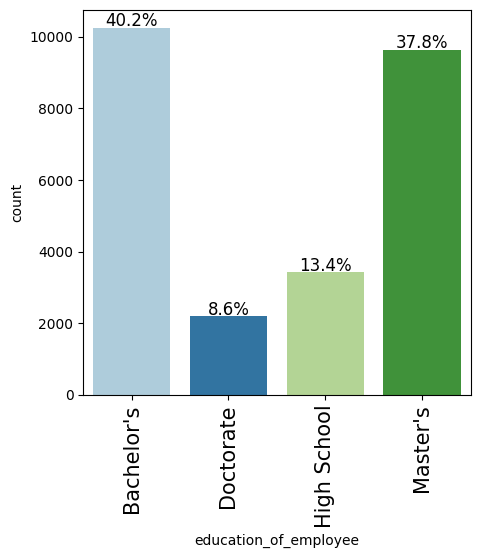

In [30]:
labeled_barplot(data, "education_of_employee", perc=True)

#### Observations on region of employment

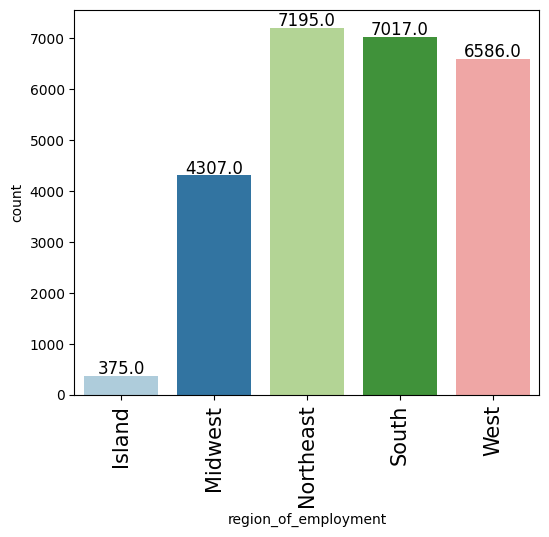

In [34]:
labeled_barplot(data, 'region_of_employment') # Adding data as the first argument


#### Observations on job experience

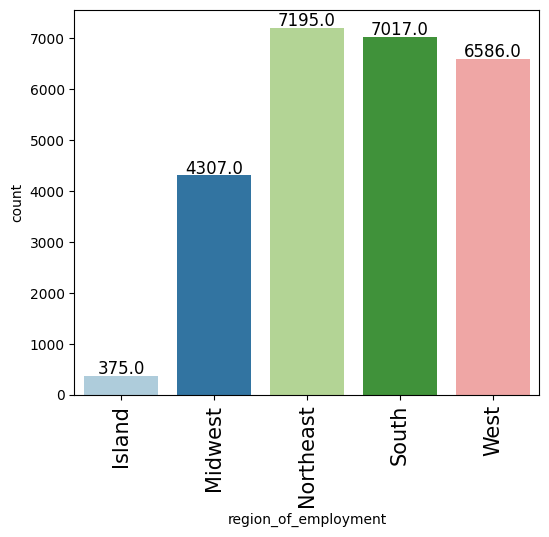

In [36]:
labeled_barplot(data, 'region_of_employment')


#### Observations on case status

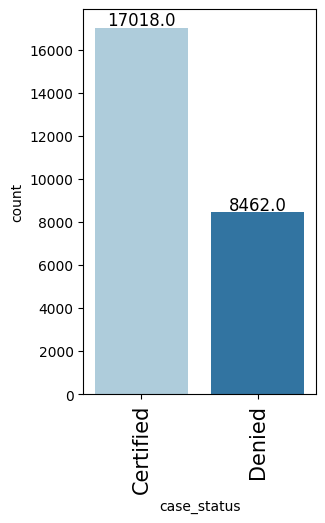

In [38]:
labeled_barplot(data, 'case_status') # Adding data as the first argument and case_status as the second argument



### Bivariate Analysis

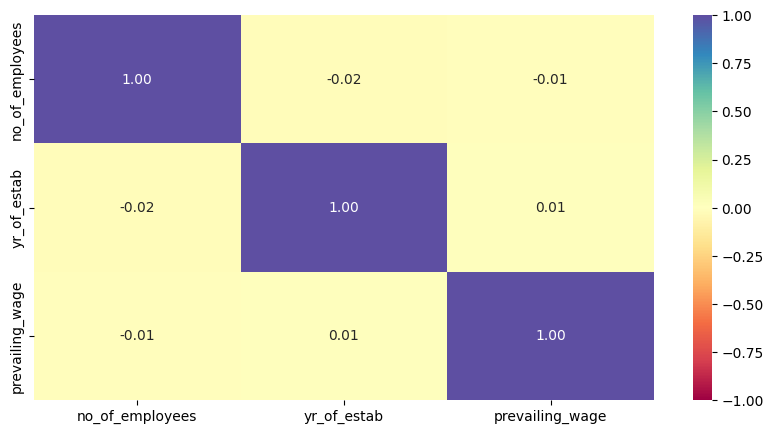

In [39]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

**Creating functions that will help us with further analysis.**

In [40]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [41]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

#### Those with higher education may want to travel abroad for a well-paid job. Let's find out if education has any impact on visa certification

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


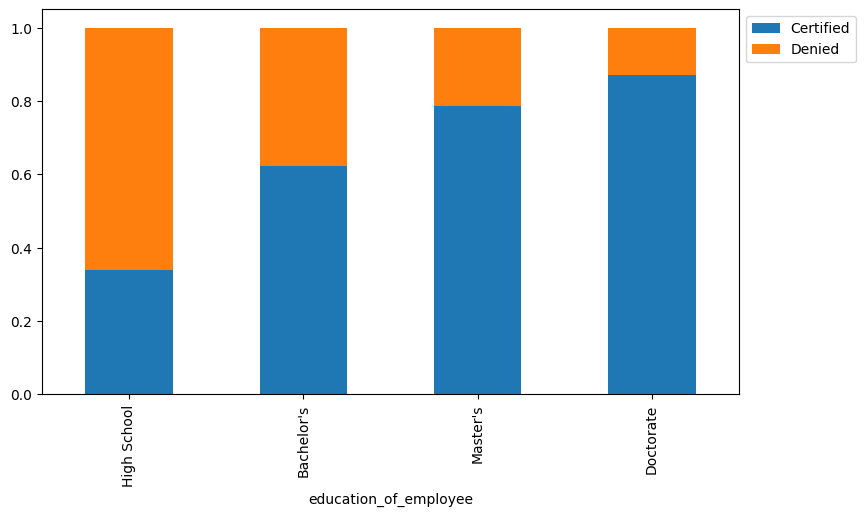

In [42]:
stacked_barplot(data, "education_of_employee", "case_status")

#### Lets' similarly check for the continents and find out how the visa status vary across different continents.

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


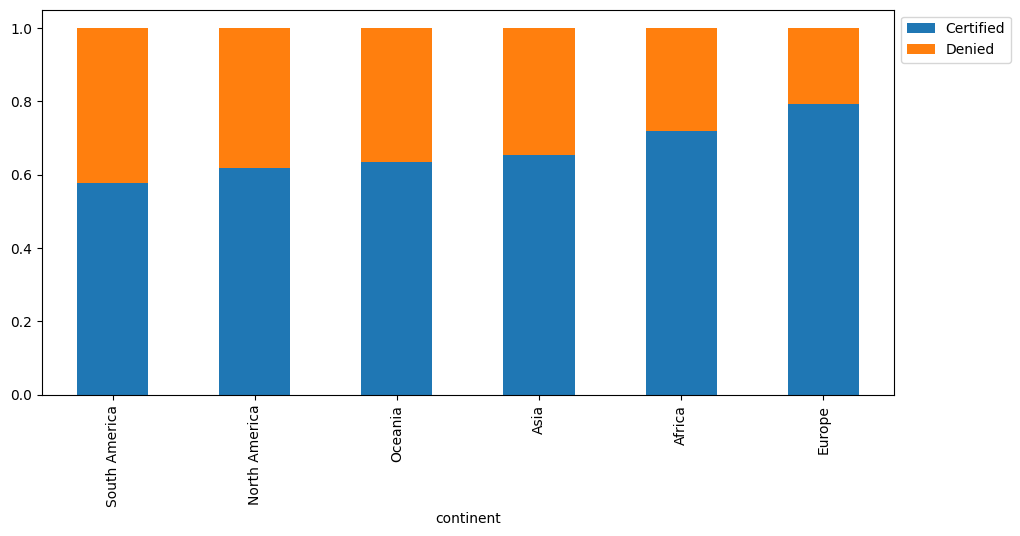

In [45]:
stacked_barplot(data, 'continent', 'case_status')


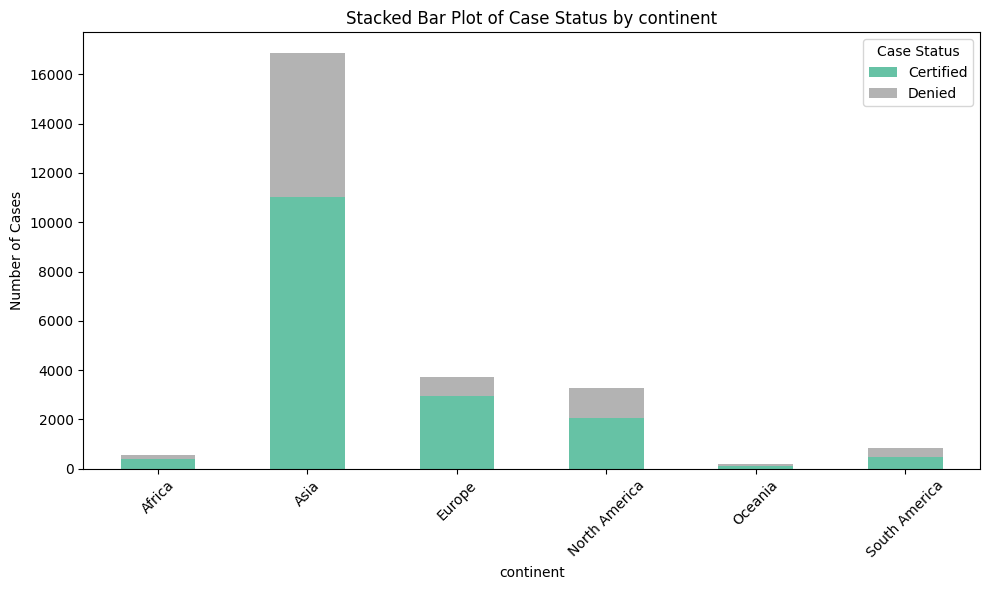

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

def stacked_barplot(column):
    ctab = pd.crosstab(data[column], data['case_status'])
    ctab.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set2')
    plt.title(f'Stacked Bar Plot of Case Status by {column}')
    plt.xlabel(column)
    plt.ylabel('Number of Cases')
    plt.xticks(rotation=45)
    plt.legend(title='Case Status')
    plt.tight_layout()
    plt.show()

# Usage:
stacked_barplot('continent')

#### Experienced professionals might look abroad for opportunities to improve their lifestyles and career development. Let's see if having work experience has any influence over visa certification

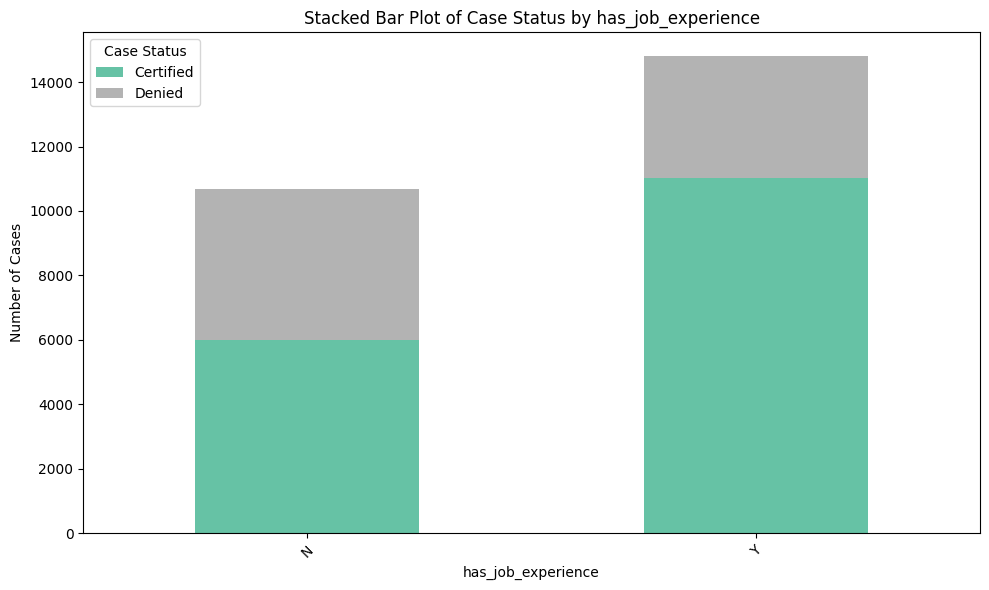

In [47]:
stacked_barplot('has_job_experience')


#### Checking if the prevailing wage is similar across all the regions of the US

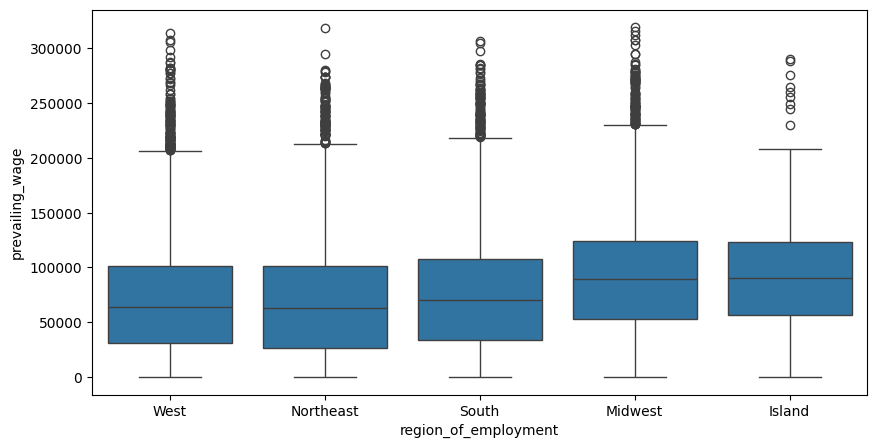

In [48]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='region_of_employment', y='prevailing_wage', data=data)
plt.show()

#### The US government has established a prevailing wage to protect local talent and foreign workers. Let's analyze the data and see if the visa status changes with the prevailing wage

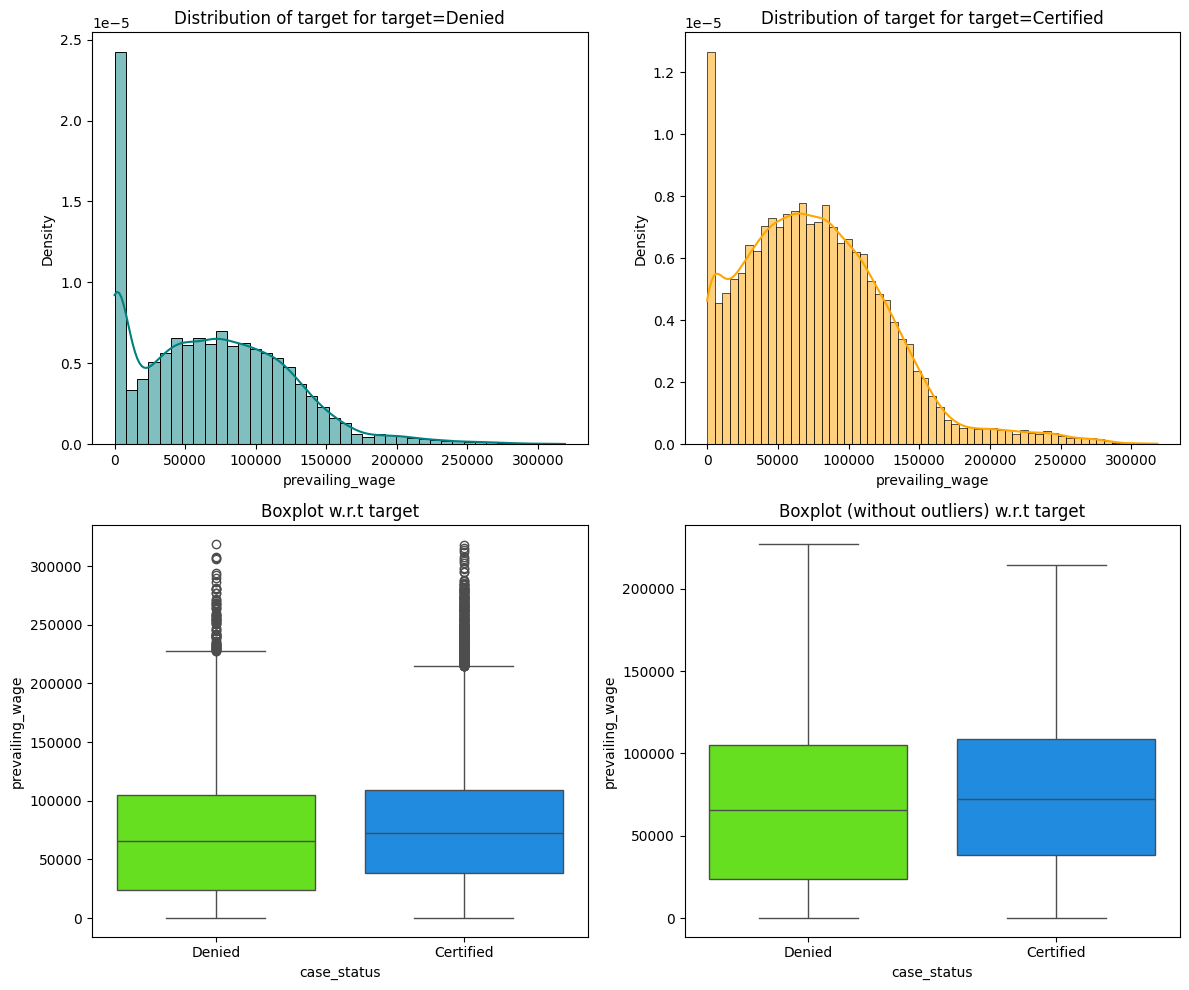

In [50]:
distribution_plot_wrt_target(data, 'prevailing_wage', 'case_status')



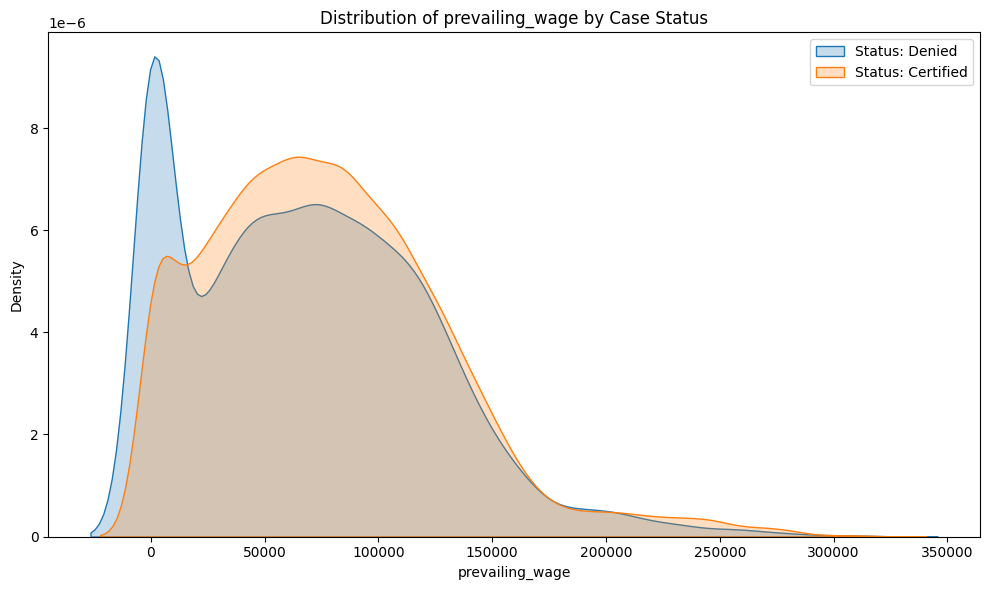

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

def distribution_plot_wrt_target(numeric_col):
    plt.figure(figsize=(10,6))
    for status in data['case_status'].unique():
        subset = data[data['case_status'] == status]
        sns.kdeplot(subset[numeric_col], label=f"Status: {status}", shade=True)

    plt.title(f'Distribution of {numeric_col} by Case Status')
    plt.xlabel(numeric_col)
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Usage
distribution_plot_wrt_target('prevailing_wage')

#### The prevailing wage has different units (Hourly, Weekly, etc). Let's find out if it has any impact on visa applications getting certified.

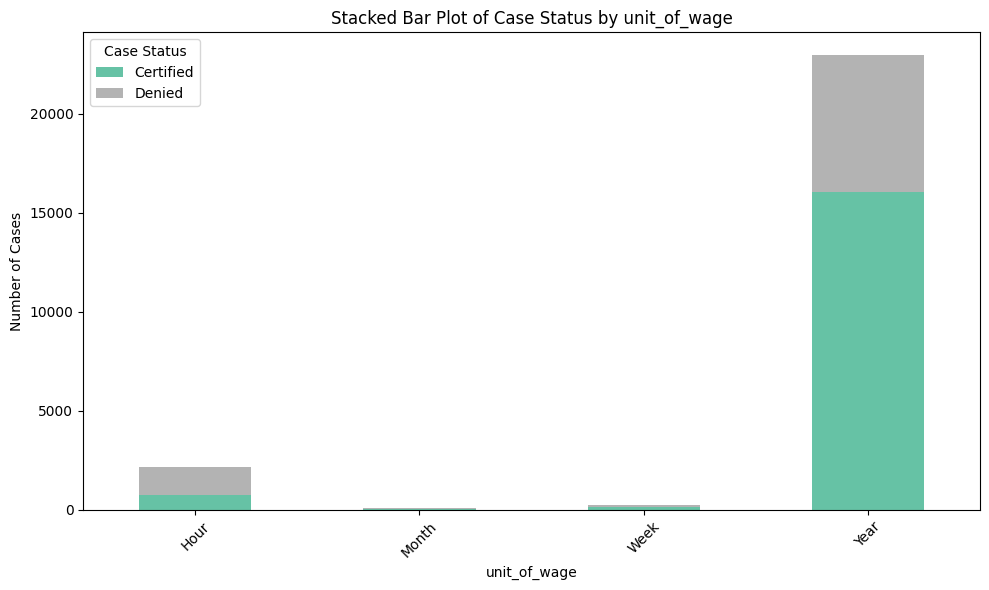

In [52]:
stacked_barplot('unit_of_wage')


## Data Pre-processing

### Outlier Check

- Let's check for outliers in the data.

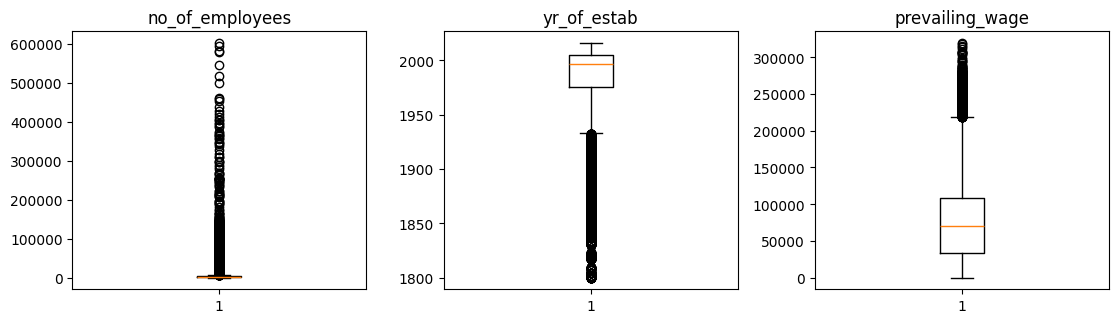

In [53]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

### Data Preparation for modeling

- We want to predict which visa will be certified.
- Before we proceed to build a model, we'll have to encode categorical features.
- We'll split the data into train and test to be able to evaluate the model that we build on the train data.

In [54]:
data["case_status"] = data["case_status"].apply(lambda x: 1 if x == "Certified" else 0)

# ✅ Drop the target column from X
X = data.drop("case_status", axis=1)
y = data["case_status"]

# ✅ Create dummy variables for categorical columns
X = pd.get_dummies(X, drop_first=True)

# ✅ Split into train and validation sets (70% train, 30% val)
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

# ✅ Further split validation set into validation and test sets (90% val, 10% test)
X_val, X_test, y_val, y_test = train_test_split(
    X_val, y_val, test_size=0.1, random_state=1, stratify=y_val
)


In [55]:
print("Validation set class distribution:\n", y_val.value_counts())

Validation set class distribution:
 case_status
1    4594
0    2285
Name: count, dtype: int64


In [57]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

In [81]:
print("Shape of Training set : ", X_train.shape)
print("Shape of Validation set : ", X_val.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in validation set:")
print(y_val.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (17836, 21)
Shape of Validation set :  (6879, 21)
Shape of test set :  (765, 21)
Percentage of classes in training set:
case_status
0    1.0
Name: proportion, dtype: float64
Percentage of classes in validation set:
case_status
0    1.0
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
0    1.0
Name: proportion, dtype: float64


## Model Building

### Model Evaluation Criterion

Provide some reasoning for choosing the metric here : ______

First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.
* The model_performance_classification_sklearn function will be used to check the model performance of models.
* The confusion_matrix_sklearn function will be used to plot the confusion matrix.

In [58]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [59]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

#### Defining scorer to be used for cross-validation and hyperparameter tuning

In [64]:
scorer = metrics.make_scorer(metrics.f1_score)


In [65]:
X_train = X_train.astype(int)
X_val = X_val.astype(int)

In [66]:
X = X.astype(int)
X_test = X_test.astype(int)

In [69]:
print("\nCross-Validation performance on training dataset:\n")

results1 = []  # Initialize results1 as an empty list to store CV results
names = []  # Initialize names as an empty list to store model names

for name, model in models:
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

    try:
        cv_result = cross_val_score(estimator=model, X=X_train, y=y_train, scoring=scorer, cv=kfold)
        results1.append(cv_result)
        print(f"{name}: {cv_result.mean():.4f}")
    except ValueError as e:
        print(f"Error during cross-validation for {name}: {e}")
        dummy_result = np.array([np.nan]*5)  # Fake result to keep structure
        results1.append(dummy_result)
        print(f"{name}: Failed (NaN)")

    names.append(name)



Cross-Validation performance on training dataset:

Bagging: 0.7746
Random forest: 0.8037
GBM: 0.8228
Adaboost: 0.8203
Xgboost: 0.8083
dtree: 0.7431


**We are now done with pre-processing and evaluation criterion, so let's start building the model.**

### Model building with original data

In [70]:
import numpy as np

print("\nCross-Validation performance on training dataset:\n")

for name, model in models:
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

    try:
        cv_result = cross_val_score(estimator=model, X=X_train, y=y_train, scoring=scorer, cv=kfold)
        results1.append(cv_result)
        print(f"{name}: {cv_result.mean():.4f}")
    except ValueError as e:
        print(f"Error during cross-validation for {name}: {e}")
        results1.append(np.array([np.nan]*5))  # Ensure consistent shape

    names.append(name)

print("\nValidation Performance:\n")

for name, model in models:
    try:
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)
        score = metrics.f1_score(y_val, val_pred)
        print(f"{name}: {score:.4f}")
    except Exception as e:
        print(f"{name} failed on validation: {e}")


Cross-Validation performance on training dataset:

Bagging: 0.7746
Random forest: 0.8037
GBM: 0.8228
Adaboost: 0.8203
Xgboost: 0.8083
dtree: 0.7431

Validation Performance:

Bagging: 0.7702
Random forest: 0.7964
GBM: 0.8197
Adaboost: 0.8158
Xgboost: 0.8086
dtree: 0.7462


In [71]:
print(X_train.isnull().sum().sum())
print(np.isinf(X_train).sum().sum())
print(X_train.dtypes)

0
0
no_of_employees                      int64
yr_of_estab                          int64
prevailing_wage                      int64
continent_Asia                       int64
continent_Europe                     int64
continent_North America              int64
continent_Oceania                    int64
continent_South America              int64
education_of_employee_Doctorate      int64
education_of_employee_High School    int64
education_of_employee_Master's       int64
has_job_experience_Y                 int64
requires_job_training_Y              int64
region_of_employment_Midwest         int64
region_of_employment_Northeast       int64
region_of_employment_South           int64
region_of_employment_West            int64
unit_of_wage_Month                   int64
unit_of_wage_Week                    int64
unit_of_wage_Year                    int64
full_time_position_Y                 int64
dtype: object


In [72]:
print(X_train.dtypes)

no_of_employees                      int64
yr_of_estab                          int64
prevailing_wage                      int64
continent_Asia                       int64
continent_Europe                     int64
continent_North America              int64
continent_Oceania                    int64
continent_South America              int64
education_of_employee_Doctorate      int64
education_of_employee_High School    int64
education_of_employee_Master's       int64
has_job_experience_Y                 int64
requires_job_training_Y              int64
region_of_employment_Midwest         int64
region_of_employment_Northeast       int64
region_of_employment_South           int64
region_of_employment_West            int64
unit_of_wage_Month                   int64
unit_of_wage_Week                    int64
unit_of_wage_Year                    int64
full_time_position_Y                 int64
dtype: object


In [73]:
X_train = pd.get_dummies(X_train, drop_first=True)

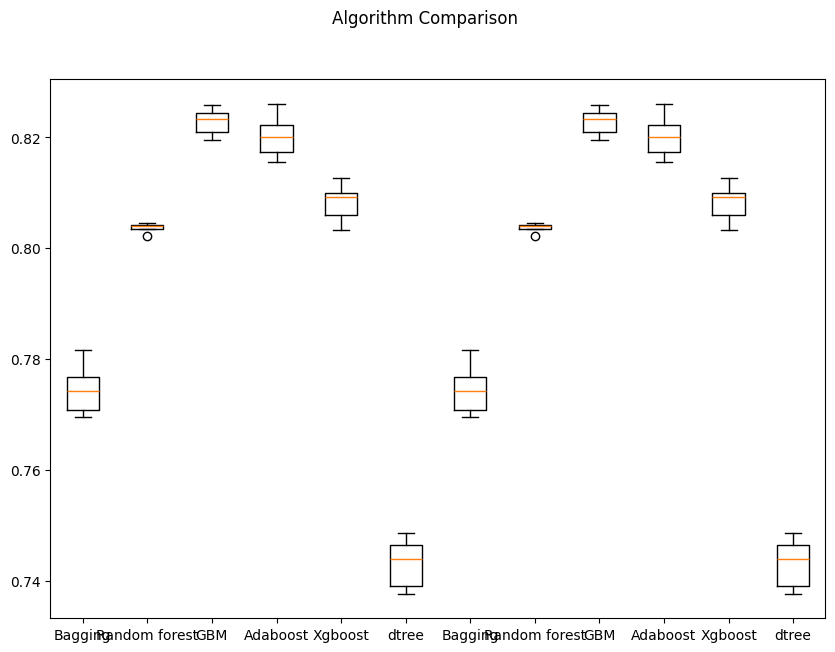

In [74]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

### Model Building with oversampled data

In [75]:
print("Before OverSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y_train == 0)))

from imblearn.over_sampling import SMOTE

# Example: balance the classes fully using 5 nearest neighbors
sm = SMOTE(sampling_strategy='auto', k_neighbors=5, random_state=1)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After OverSampling, counts of label '1': {}".format(sum(y_train_over == 1)))
print("After OverSampling, counts of label '0': {} \n".format(sum(y_train_over == 0)))


print("After OverSampling, the shape of train_X: {}".format(X_train_over.shape))
print("After OverSampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before OverSampling, counts of label '1': 11913
Before OverSampling, counts of label '0': 5923 

After OverSampling, counts of label '1': 11913
After OverSampling, counts of label '0': 11913 

After OverSampling, the shape of train_X: (23826, 21)
After OverSampling, the shape of train_y: (23826,) 



In [76]:
print("Before OverSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y_train == 0)))

Before OverSampling, counts of label '1': 11913
Before OverSampling, counts of label '0': 5923 



In [79]:
models = []  # Empty list to store all the models

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  ## Complete the code to set the number of splits
    cv_result = cross_val_score(
        estimator=model, X=X_train_over, y=y_train_over,scoring = scorer, cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)  # ✅ Fit on oversampled data
    scores = metrics.f1_score(y_val, model.predict(X_val))  # ✅ Use F1 score for evaluation
    print(f"{name}: {scores:.4f}")


Cross-Validation performance on training dataset:

Bagging: 0.7645094193265606
Random forest: 0.790141632314238
GBM: 0.8003499386189723
Adaboost: 0.7673183860932407
Xgboost: 0.7957295067586931
dtree: 0.7316720501500157

Validation Performance:

Bagging: 0.7591
Random forest: 0.7858
GBM: 0.8010
Adaboost: 0.7759
Xgboost: 0.7956
dtree: 0.7434


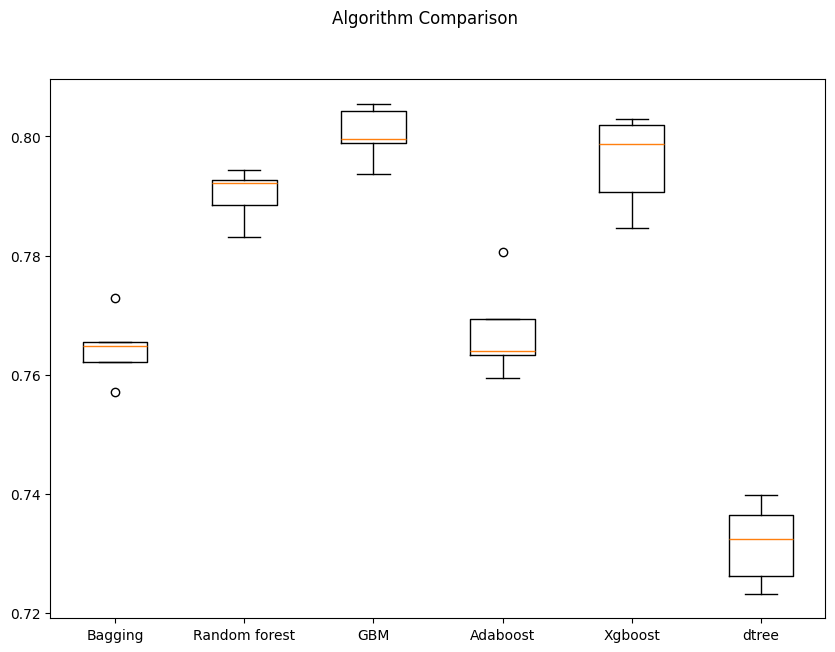

In [80]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

### Model Building with undersampled data

In [81]:
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)


print("Before UnderSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before UnderSampling, counts of label '0': {} \n".format(sum(y_train == 0)))


print("After UnderSampling, counts of label '1': {}".format(sum(y_train_un == 1)))
print("After UnderSampling, counts of label '0': {} \n".format(sum(y_train_un == 0)))


print("After UnderSampling, the shape of train_X: {}".format(X_train_un.shape))
print("After UnderSampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before UnderSampling, counts of label '1': 11913
Before UnderSampling, counts of label '0': 5923 

After UnderSampling, counts of label '1': 5923
After UnderSampling, counts of label '0': 5923 

After UnderSampling, the shape of train_X: (11846, 21)
After UnderSampling, the shape of train_y: (11846,) 



In [86]:
# Assuming the models list is already defined as before
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )
    # Remove n_jobs=-1 or set it to 1
    cv_result = cross_val_score(
        estimator=model, X=X_train_un, y=y_train_un, scoring=scorer, cv=kfold #, n_jobs=1
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")
for name, model in models:
    model.fit(X_train_un, y_train_un)  # ✅ Fit the model on the undersampled training set
    scores = metrics.f1_score(y_val, model.predict(X_val))  # ✅ Use F1 score for evaluation
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset:

Bagging: 0.6419229374670421
Random forest: 0.6914492647064355
GBM: 0.7126519891275951
Adaboost: 0.6961843967344691
Xgboost: 0.6901436620014397
dtree: 0.6192988757772475

Validation Performance:

Bagging: 0.6898781397662274
Random forest: 0.7370674277559758
GBM: 0.7616495806150979
Adaboost: 0.7604202747950584
Xgboost: 0.7442464298359495
dtree: 0.6828975773566802


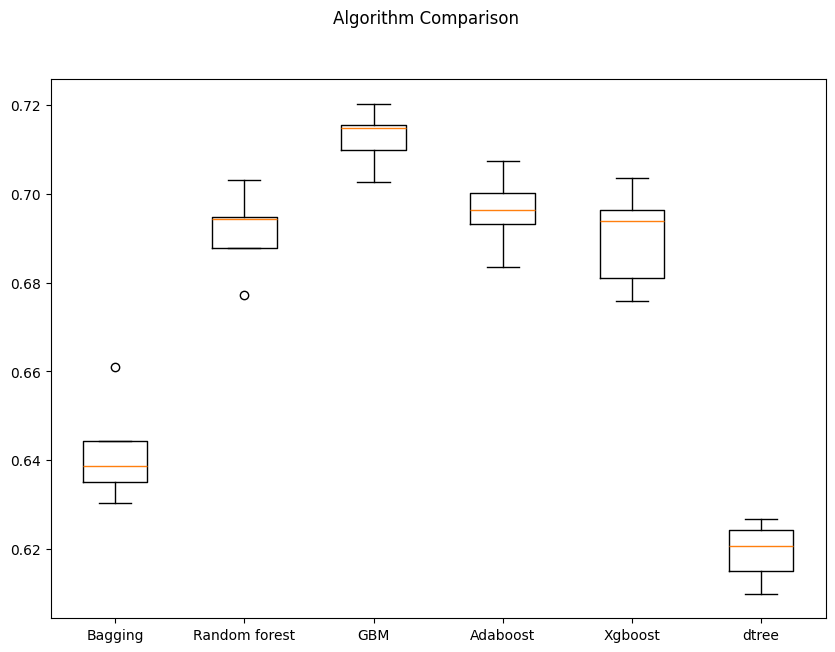

In [87]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

## Hyperparameter Tuning

### Tuning AdaBoost using oversampled data

In [93]:
%%time

# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomizedSearchCV
param_grid = {
    "n_estimators": [50, 100, 150, 200],           # ✅ Number of boosting rounds
    "learning_rate": [0.01, 0.1, 0.2, 0.3],         # ✅ Step size shrinkage
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}


#Calling RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, n_jobs = -1, scoring=scorer, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1), random_state=1)  ## Complete the code to set the cv parameter

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 150, 'learning_rate': 0.1, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.8001322089670412:
CPU times: user 16.3 s, sys: 3.99 s, total: 20.3 s
Wall time: 13min 22s


In [92]:
!pip install numpy --upgrade --user

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 35.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.25.2
    Uninstalling numpy-1.25.2:
      Successfully uninstalled numpy-1.25.2
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 1.5.3 which is incompatible.
mizani 0.13.3 requires pandas>=2.2.0, but you have pandas 1.5.3 which is incompatible.
plotnine 0.14.5 requires matplotlib>=3.8.0, but you have matplotlib 3.7.1 which is incompatible.
plotnine 0.14.5 requires pandas>=2.2.0, but you have pandas 1.5.3 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=

In [94]:
# Example using best parameters from randomized_cv
best_params = randomized_cv.best_params_

tuned_ada = AdaBoostClassifier(
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['learning_rate'],
    estimator=best_params['estimator']
)

tuned_ada.fit(X_train_over, y_train_over)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=0.1, n_estimators=150)

In [95]:
# ✅ Complete code to evaluate AdaBoost on validation data
ada_val_perf = model_performance_classification_sklearn(tuned_ada, X_val, y_val)
ada_val_perf

,Accuracy,Recall,Precision,F1
0,0.728304,0.817588,0.784625,0.800768


*italicized text*### Tuning Random forest using undersampled data

In [102]:
# Re-import required libraries after code execution environment reset
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score
from sklearn.utils import parallel_backend
from sklearn.datasets import make_classification

# Simulate undersampled training data (as placeholder)
X_train_under, y_train_under = make_classification(
    n_samples=1000, n_features=20, n_informative=10, n_redundant=5,
    n_classes=2, weights=[0.7, 0.3], random_state=1
)

# Define F1 scorer
scorer = make_scorer(f1_score)

# Define the model
Model = RandomForestClassifier(random_state=1)

# Define the parameter grid
param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "min_samples_leaf": np.arange(1, 5),
    "max_features": [3, 4, 5, 6, 7, 8, 9, 'sqrt'],
    "max_samples": np.arange(0.5, 1.0, 0.1)
}

# Define cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

# Set up RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=Model,
    param_distributions=param_grid,
    n_iter=50,
    n_jobs=-1,
    scoring=scorer,
    cv=cv_strategy,
    random_state=1,
    verbose=1
)

# Fit the model using all CPU cores
with parallel_backend('loky'):
    randomized_cv.fit(X_train_under, y_train_under)

# Extract best parameters and score
best_params = randomized_cv.best_params_
best_score = randomized_cv.best_score_

best_params, best_score

Fitting 5 folds for each of 50 candidates, totalling 250 fits


({'n_estimators': 300,
  'min_samples_leaf': np.int64(1),
  'max_samples': np.float64(0.8999999999999999),
  'max_features': 'sqrt'},
 np.float64(0.853383723386775))

In [103]:
# Complete the code to define the best model
tuned_rf2 = RandomForestClassifier(
    max_features=best_params['max_features'],
    random_state=1,
    max_samples=best_params['max_samples'],
    n_estimators=best_params['n_estimators'],
    min_samples_leaf=best_params['min_samples_leaf'],
)

tuned_rf2.fit(X_train_un, y_train_un)

RandomForestClassifier(max_samples=np.float64(0.8999999999999999),
                       min_samples_leaf=np.int64(1), n_estimators=300,
                       random_state=1)

In [104]:
rf2_train_perf = model_performance_classification_sklearn(
    tuned_rf2, X_train_un, y_train_un
)
rf2_train_perf

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


In [105]:
## Complete the code to print the model performance on the validation data.
rf2_val_perf = model_performance_classification_sklearn(tuned_rf2, X_val, y_val)
rf2_val_perf

,Accuracy,Recall,Precision,F1
0,0.676697,0.674358,0.809723,0.735867


### Tuning with Gradient boosting with oversampled data

In [106]:
%%time

# defining model
Model = GradientBoostingClassifier(random_state=1)

param_grid = {
    "n_estimators": np.arange(50, 301, 50),        # Number of trees: 50, 100, 150, 200, 250, 300
    "learning_rate": [0.01, 0.05, 0.1, 0.2],       # Step size shrinkage
    "subsample": [0.7, 1.0],                      # Fraction of samples used per tree
    "max_features": ['sqrt', 'log2']              # Feature selection per tree
}

from sklearn.model_selection import StratifiedKFold

randomized_cv = RandomizedSearchCV(
    estimator=Model,
    param_distributions=param_grid,
    scoring=scorer,
    n_iter=50,
    n_jobs=-1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),  # ✅ Complete here
    random_state=1
)
#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 1.0, 'n_estimators': np.int64(250), 'max_features': 'log2', 'learning_rate': 0.1} with CV score=0.8019643898445012:
CPU times: user 7.76 s, sys: 3.48 s, total: 11.2 s
Wall time: 6min 30s


In [107]:
# Define the best model using tuned hyperparameters
best_params = randomized_cv.best_params_

tuned_gbm = GradientBoostingClassifier(
    max_features=best_params['max_features'],
    random_state=1,
    learning_rate=best_params['learning_rate'],
    n_estimators=best_params['n_estimators'],
    subsample=best_params['subsample']
)

# Fit the model on oversampled training data
tuned_gbm.fit(X_train_over, y_train_over)


GradientBoostingClassifier(max_features='log2', n_estimators=np.int64(250),
                           random_state=1)

In [108]:
gbm_train_perf = model_performance_classification_sklearn(
    tuned_gbm, X_train_over, y_train_over
)
gbm_train_perf

,Accuracy,Recall,Precision,F1
0,0.803618,0.83539,0.785478,0.809665


In [109]:
## Complete the code to print the model performance on the validation data.
gbm_val_perf = model_performance_classification_sklearn(tuned_gbm, X_val, y_val)
gbm_val_perf

,Accuracy,Recall,Precision,F1
0,0.729176,0.821942,0.78324,0.802124


### Tuning XGBoost using oversampled data

In [113]:
%%time

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

# Define model
Model = XGBClassifier(random_state=1, eval_metric='logloss', use_label_encoder=False)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'scale_pos_weight': [1, 3, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'gamma': [0, 1, 5],
    'subsample': [0.7, 0.8, 1.0]
}

# Define scorer
scorer = make_scorer(f1_score)

# Set cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

# Call RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=Model,
    param_distributions=param_grid,
    n_iter=50,
    n_jobs=-1,
    scoring=scorer,
    cv=cv,
    random_state=1,
    verbose=1
)

# Fit on oversampled data
randomized_cv.fit(X_train_over, y_train_over)

# Print best results
print("Best parameters are {} with CV score={}".format(
    randomized_cv.best_params_, randomized_cv.best_score_))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters are {'subsample': 1.0, 'scale_pos_weight': 1, 'n_estimators': 300, 'learning_rate': 0.1, 'gamma': 5} with CV score=0.8054390027228093
CPU times: user 3.92 s, sys: 3 s, total: 6.92 s
Wall time: 2min 48s


In [114]:
best_params = randomized_cv.best_params_

xgb2 = XGBClassifier(
    random_state=1,
    eval_metric='logloss',  # ✅ Standard for binary classification
    subsample=best_params['subsample'],
    scale_pos_weight=best_params['scale_pos_weight'],
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['learning_rate'],
    gamma=best_params['gamma']
)

xgb2.fit(X_train_over, y_train_over)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=5, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, random_state=1, ...)

In [115]:
xgb2_train_perf = model_performance_classification_sklearn(
    xgb2, X_train_over, y_train_over
)
xgb2_train_perf

,Accuracy,Recall,Precision,F1
0,0.804625,0.832704,0.788428,0.809961


In [116]:
# Complete the code to print the model performance on the validation data.
xgb2_val_perf = model_performance_classification_sklearn(xgb2, X_val, y_val)
xgb2_val_perf

,Accuracy,Recall,Precision,F1
0,0.731502,0.821942,0.785848,0.80349


**We have now tuned all the models, let's compare the performance of all tuned models and see which one is the best.**

## Model performance comparison and


In [119]:
# ✅ Fit the tuned AdaBoost model on the training data
tuned_ada.fit(X_train_over, y_train_over)

# ✅ Evaluate AdaBoost's performance on the training data
ada_train_perf = model_performance_classification_sklearn(tuned_ada, X_train_over, y_train_over)


# Ensure all performance dicts are turned into aligned DataFrames
models_train_comp_df = pd.concat(
    [
        pd.DataFrame(gbm_train_perf).T,
        pd.DataFrame(xgb2_train_perf).T,
        pd.DataFrame(ada_train_perf).T,
        pd.DataFrame(rf2_train_perf).T,
    ],
    axis=1
)

models_train_comp_df.columns = [
    "Gradient Boosting tuned with oversampled data",
    "XGBoost tuned with oversampled data",
    "AdaBoost tuned with oversampled data",
    "Random forest tuned with undersampled data",
]

print("Training performance comparison:")
models_train_comp_df


Training performance comparison:


,Gradient Boosting tuned with oversampled data,XGBoost tuned with oversampled data,AdaBoost tuned with oversampled data,Random forest tuned with undersampled data
Accuracy,0.803618,0.804625,0.796441,1.0
Recall,0.835390,0.832704,0.821120,1.0
Precision,0.785478,0.788428,0.782497,1.0
F1,0.809665,0.809961,0.801343,1.0


In [120]:
# validation performance comparison

models_val_comp_df = pd.concat(
    [
        gbm_val_perf.T,
        xgb2_val_perf.T,
        ada_val_perf.T,
        rf2_val_perf.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Gradient Boosting tuned with oversampled data",
    "XGBoost tuned with oversampled data",
    "AdaBoost tuned with oversampled data",
    "Random forest tuned with undersampled data",
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Gradient Boosting tuned with oversampled data,XGBoost tuned with oversampled data,AdaBoost tuned with oversampled data,Random forest tuned with undersampled data
Accuracy,0.729176,0.731502,0.728304,0.676697
Recall,0.821942,0.821942,0.817588,0.674358
Precision,0.783240,0.785848,0.784625,0.809723
F1,0.802124,0.803490,0.800768,0.735867


In [122]:
test = model_performance_classification_sklearn(xgb2, X_test, y_test)
test

,Accuracy,Recall,Precision,F1
0,0.755556,0.849315,0.797794,0.822749


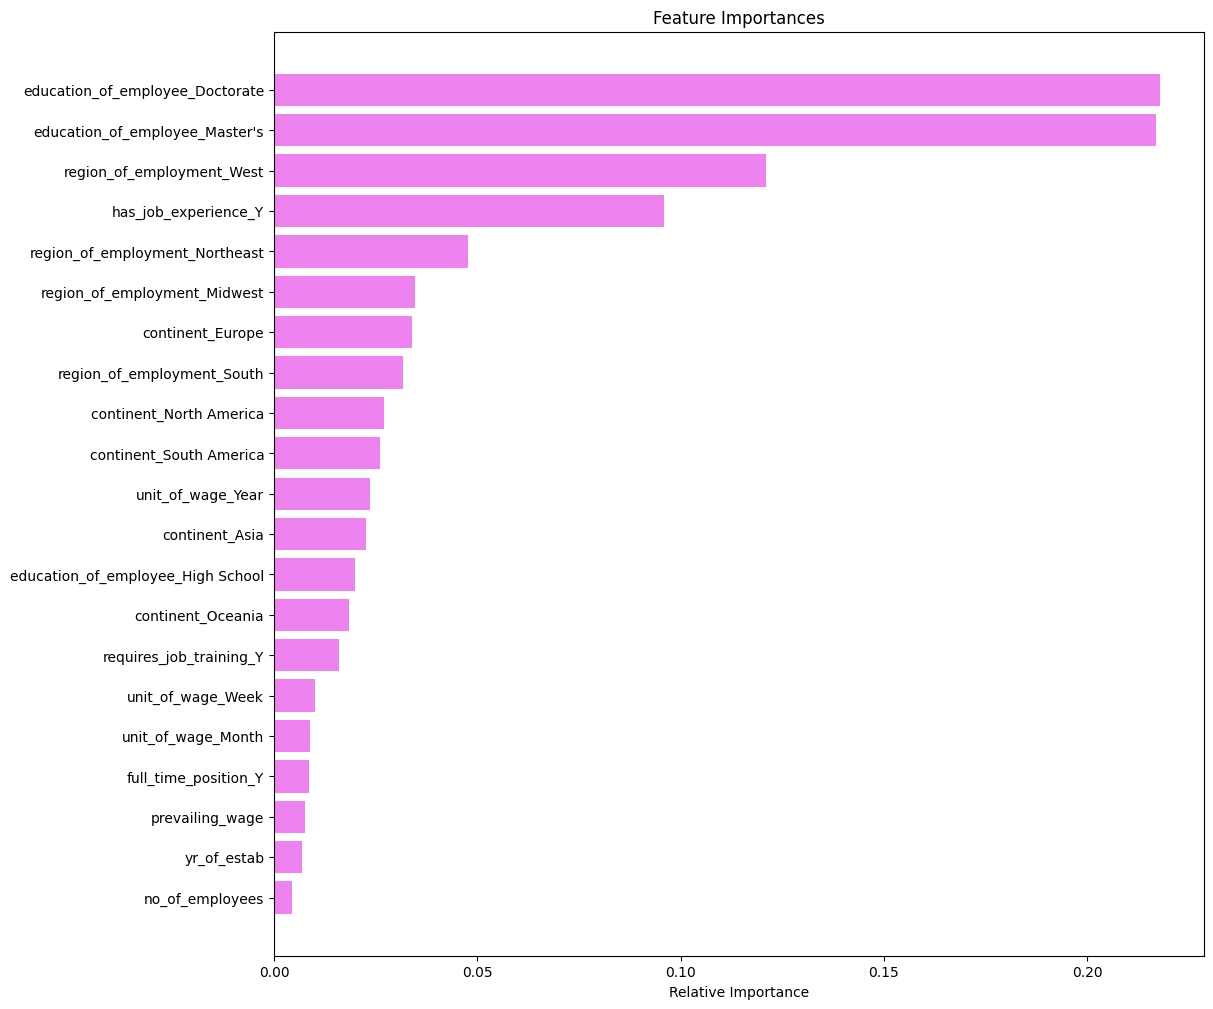

In [124]:
feature_names = X_train.columns
importances = xgb2.feature_importances_  # ✅ Extract feature importances

indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

## Actionable Insights and Recommendations

<font size=6 color='blue'>Power Ahead</font>
___